In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
class MaskedImageDataset(Dataset):
    def __init__(self, data_dir, categories, transform=None, sample_size=None):
        self.image_paths = []
        self.mask_paths = []
        self.labels = []
        self.class_names = []
        self.transform = transform
        self.label_map = {cat: i for i, cat in enumerate(categories)}
        self.inv_label_map = {i: cat for cat, i in self.label_map.items()}  # Szám → név átalakítás

        for category in categories:
            images_path = os.path.join(data_dir, category, "images")
            masks_path = os.path.join(data_dir, category, "masks")
            
            if not os.path.isdir(images_path) or not os.path.isdir(masks_path):
                continue
            
            files = os.listdir(images_path)
            if sample_size:  # If sample_size is given, limit the number of files
                files = files[:sample_size]  
                
            for file in tqdm(files, desc=f"Loading {category} images"):
                img_path = os.path.join(images_path, file)
                mask_path = os.path.join(masks_path, file)
                
                if os.path.exists(mask_path):
                    self.image_paths.append(img_path)
                    self.mask_paths.append(mask_path)
                    self.labels.append(self.label_map[category])
                    self.class_names.append(category)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        label = self.labels[idx]
    
        # Load images and masks
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale
    
        # Resize both image and mask
        fixed_size = (256, 256)
        image = image.resize(fixed_size, Image.BILINEAR)
        mask = mask.resize(fixed_size, Image.NEAREST)
    
        # Apply transforms
        if self.transform:
            image = self.transform(image)  # apply full transform to image
        mask = transforms.ToTensor()(mask)  # only convert mask to tensor
    
        # Convert mask to binary (0 or 1)
        mask = (mask > 0.5).float()
    
        # Ensure mask has 3 channels like the image
        mask = mask.expand(3, -1, -1)  # shape [3, 256, 256]
    
        # Ensure shape match
        assert image.shape == mask.shape, f"Shape mismatch: {image.shape} vs {mask.shape}"
    
        # Apply mask to image
        masked_image = image * mask
    
        return masked_image, label


In [3]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # ResNet bemeneti mérete
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = MaskedImageDataset(data_dir='/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset',
                             categories=["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"],
                             transform=transform,
                             sample_size=None)

num_classes = len(dataset.label_map)
print(num_classes)

Loading Lung_Opacity images: 100%|██████████| 6012/6012 [00:16<00:00, 363.78it/s]

4


In [4]:
# Define split ratios
train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

total_size = len(dataset)
train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

def count_per_category(dataset):
    category_counts = {cat: 0 for cat in dataset.dataset.label_map.keys()}
    
    for _, label in dataset:
        category_name = dataset.dataset.inv_label_map[label]
        category_counts[category_name] += 1
    
    return category_counts

print("Training Set Distribution:", count_per_category(train_dataset))
print("Validation Set Distribution:", count_per_category(val_dataset))
print("Test Set Distribution:", count_per_category(test_dataset))

Training Set Distribution: {'COVID': 2918, 'Normal': 8129, 'Viral Pneumonia': 1071, 'Lung_Opacity': 4814}
Validation Set Distribution: {'COVID': 369, 'Normal': 1017, 'Viral Pneumonia': 132, 'Lung_Opacity': 598}
Test Set Distribution: {'COVID': 329, 'Normal': 1046, 'Viral Pneumonia': 142, 'Lung_Opacity': 600}


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4, input_size=(3, 256, 256), conv_layers=[(3, 32), (32, 64), (64, 128), (128, 256), (256, 512)]):
        super(CustomCNN, self).__init__()
        
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        
        for in_channels, out_channels in conv_layers:
            self.convs.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1))
            self.bns.append(nn.BatchNorm2d(out_channels))
        
        # Calculate the output size dynamically
        self.flattened_size = self._get_flattened_size(input_size)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)
        
        self.dropout = nn.Dropout(0.3)
        self._initialize_weights()
    
    def _initialize_weights(self):
        print(self.modules)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def _get_flattened_size(self, input_size):
        # Create a dummy input tensor
        x = torch.zeros(1, *input_size)
        
        # Pass the input through the convolutional layers and pooling
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x)))  # Apply conv + batch norm + relu
            x = F.max_pool2d(x, kernel_size=2, stride=2)  # Apply max pooling
        
        # Return the flattened size
        return x.view(1, -1).size(1)


    
    def forward(self, x):
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x)))
            x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x


In [24]:
num_classes = len(dataset.label_map)
print(num_classes)

4


In [25]:



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training Loop
num_epochs = 10
num_workers = os.cpu_count()  # Returns the number of CPU cores

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,num_workers=num_workers)

In [26]:
import torch
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device='cuda', patience_es=5,patience_rlr=3 , save_path="best_model.pth"):
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'epoch_time': [],
        'learning_rate': []
    }
    
    model.to(device)
    
    # Scheduler: Reduce learning rate when validation loss plateaus
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience_rlr, verbose=True)

    # Early stopping
    best_val_loss = float('inf')
    early_stop_counter = 0
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        # Scheduler step (based on validation loss)
        scheduler.step(val_loss)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), save_path)

        else:
            early_stop_counter += 1
            
        if early_stop_counter >= patience_es:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        epoch_time = time.time() - epoch_start
        history['epoch_time'].append(epoch_time)
        
        print(f"Epoch {epoch+1}/{num_epochs} -> "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}, "
              f"Time: {epoch_time:.2f}s")
    
    return history


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sample model — ResNet18 for classification
model = CustomCNN(num_classes)
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# DataLoader setup (assuming you already have train_loader and val_loader)
num_epochs = 50

# Train the model
history = train_model(model,
                      train_loader,
                      val_loader,
                      criterion,
                      optimizer,
                      num_epochs,
                      device,
                      patience_es=7,
                      patience_rlr=3)


<bound method Module.modules of CustomCNN(
  (convs): ModuleList(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (bns): ModuleList(
    (0): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=32768, out_features=1024, bias=True)
  (fc2): Line

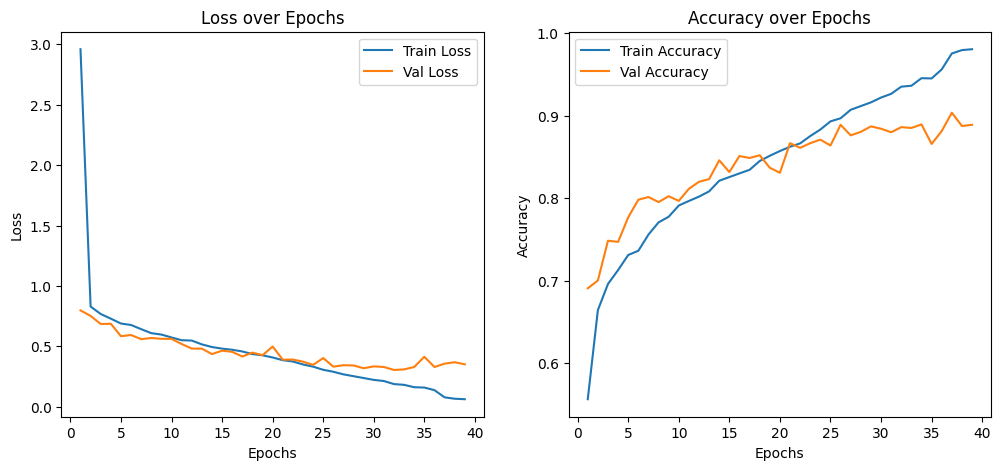

In [29]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

plot_metrics(history)


In [30]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def evaluate_model(model, dataloader, device, num_classes):
    model.eval()  # Eval mód
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # NumPy tömbök
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    # Class-wise metrics
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(all_labels, all_preds, labels=np.arange(num_classes))

    for i in range(num_classes):
        print(f"Class {i} -> Precision: {precision_per_class[i]:.4f}, Recall: {recall_per_class[i]:.4f}, F1: {f1_per_class[i]:.4f}")
    # Pontosság
    accuracy = accuracy_score(all_labels, all_preds)

    # Precision, Recall, F1 (weighted átlag)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

    # Konfúziós mátrix (kényszerített kategóriák száma)
    conf_matrix = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    # Eredmények kiíratása
    print(f" Accuracy: {accuracy:.4f}")
    print(f" Precision: {precision:.4f}")
    print(f" Recall: {recall:.4f}")
    print(f" F1-score: {f1:.4f}")
    print(" Confusion Matrix:")
    print(conf_matrix)

    return accuracy, precision, recall, f1, conf_matrix

# Használat példa
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fontos: Győződj meg róla, hogy num_classes a megfelelő érték!
num_classes = 4  # vagy ahány kategóriád van (pl.: COVID, Normal, Pneumonia, egyéb)
accuracy, precision, recall, f1, conf_matrix = evaluate_model(model, test_loader, device, num_classes)


Class 0 -> Precision: 0.8933, Recall: 0.8146, F1: 0.8521
Class 1 -> Precision: 0.9039, Recall: 0.9446, F1: 0.9238
Class 2 -> Precision: 0.9704, Recall: 0.9225, F1: 0.9458
Class 3 -> Precision: 0.8744, Recall: 0.8583, F1: 0.8663
 Accuracy: 0.8984
 Precision: 0.8984
 Recall: 0.8984
 F1-score: 0.8978
 Confusion Matrix:
[[268  31   1  29]
 [ 10 988   3  45]
 [  0  11 131   0]
 [ 22  63   0 515]]
